In [1]:
# Key Features

# - Uses ReLU activation
# - Uses Dropout (0.5) in FC layers
# - Uses Max Pooling (not average pooling)
# - Trained using GPUs
# - Uses Data Augmentation

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [5]:
# from tensorflow.keras import models, layers

# alexnet = models.Sequential()

# alexnet.add(layers.Conv2D(
#     96, (11,11),
#     strides=4,
#     activation='relu',
#     padding='valid',
#     input_shape=(28,28,1)
# ))
# alexnet.add(layers.MaxPooling2D(pool_size=(3,3), strides=2))


# # Conv2

# alexnet.add(layers.Conv2D(
#     256, (5,5),
#     strides=1,
#     activation='relu',
#     padding='same'
# ))
# alexnet.add(layers.MaxPooling2D(pool_size=(3,3), strides=2))


# # Conv3

# alexnet.add(layers.Conv2D(384, (3,3), activation='relu', padding='same'))


# # Conv4

# alexnet.add(layers.Conv2D(384, (3,3), activation='relu', padding='same'))


# # Conv5
# alexnet.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))

# alexnet.add(layers.MaxPooling2D(pool_size=(3,3), strides=2))


# # Flatten

# alexnet.add(layers.Flatten())


# # Fully Connected Layers

# alexnet.add(layers.Dense(4096, activation='relu'))
# alexnet.add(layers.Dropout(0.5))

# alexnet.add(layers.Dense(4096, activation='relu'))
# alexnet.add(layers.Dropout(0.5))


# # Output Layer
# alexnet.add(layers.Dense(10, activation='softmax'))

In [6]:
alexnet = models.Sequential()

alexnet.add(layers.Input(shape=(28,28,1)))

alexnet.add(layers.Conv2D(96, (11,11), strides=2, activation='relu'))
alexnet.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

alexnet.add(layers.Conv2D(256, (5,5), activation='relu', padding='same'))
alexnet.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

alexnet.add(layers.Conv2D(384, (3,3), activation='relu', padding='same'))
alexnet.add(layers.Conv2D(384, (3,3), activation='relu', padding='same'))
alexnet.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))

alexnet.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

alexnet.add(layers.Flatten())

alexnet.add(layers.Dense(1024, activation='relu'))
alexnet.add(layers.Dropout(0.5))

alexnet.add(layers.Dense(512, activation='relu'))
alexnet.add(layers.Dropout(0.5))

alexnet.add(layers.Dense(10, activation='softmax'))

In [7]:
alexnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history_alexnet = alexnet.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - accuracy: 0.8736 - loss: 0.3765 - val_accuracy: 0.9787 - val_loss: 0.0888
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 89s 95ms/step - accuracy: 0.9797 - loss: 0.0909 - val_accuracy: 0.9794 - val_loss: 0.0950
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 89s 94ms/step - accuracy: 0.9840 - loss: 0.0724 - val_accuracy: 0.9824 - val_loss: 0.0879


In [9]:
test_loss, test_acc = alexnet.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9824 - loss: 0.0879
Test Accuracy: 0.9824000000953674


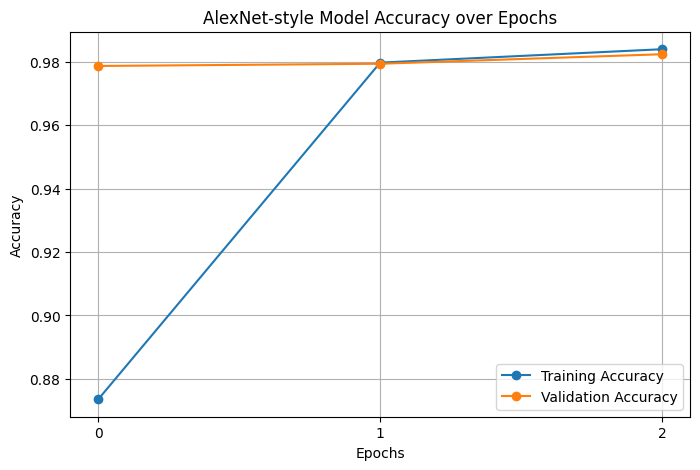

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_alexnet.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_alexnet.history['val_accuracy'], label='Validation Accuracy', marker='o')

plt.title('AlexNet-style Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(range(len(history_alexnet.history['accuracy'])))
plt.grid(True)
plt.legend()
plt.show()

# Why LeNet-5 is preferred for MNIST over AlexNet-style CNN

In [14]:
# 1. MNIST is a simple dataset
# - 28x28 grayscale images
# - simple patterns (edges, curves, digits)
# - does not need very deep networks

# 2. LeNet-5 matches dataset complexity
# - fewer layers
# - smaller filters
# - designed specifically for handwritten digits

# 3. Faster and efficient
# - less computation
# - faster training
# - lower memory usage

# 4. Similar accuracy
# - LeNet-5 gives ~98% accuracy
# - AlexNet-style gives ~98–99%
# - improvement is very small

# 5. AlexNet is overkill for MNIST
# - too many parameters
# - deep architecture not needed for simple images


# 7. Better for learning and comparison
# - LeNet is used as baseline CNN model
# - helps understand CNN fundamentals clearly